In [1]:
!pip install -q imbalanced-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve,
    classification_report,
    confusion_matrix
)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

sns.set_style("whitegrid")

print("All libraries imported successfully!")

All libraries imported successfully!


In [3]:
from google.colab import files

uploaded = files.upload()

Saving credit_card_fraud_10k.csv to credit_card_fraud_10k.csv


In [4]:
import pandas as pd

df = pd.read_csv("credit_card_fraud_10k.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully!
Shape: (10000, 10)


,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0


In [5]:
print("Dataset Information:")
df.info()

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  object 
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), object(1)
memory usage: 781.4+ KB


In [6]:
df.describe(include="all")

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
unique,NaN,NaN,NaN,5,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,NaN,Food,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,NaN,2093,NaN,NaN,NaN,NaN,NaN,NaN
mean,5000.50000,175.949849,11.593300,NaN,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,NaN,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,NaN,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,NaN,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,NaN,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,NaN,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000


In [7]:
missing_values = df.isnull().sum()

print("Missing Values:")
print(missing_values)

print("\nTotal Missing Values:", missing_values.sum())

Missing Values:
transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

Total Missing Values: 0


In [8]:
duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

Number of duplicate rows: 0


In [9]:
possible_targets = [
    "Class",
    "class",
    "Fraud",
    "fraud",
    "is_fraud",
    "Is_Fraud",
    "isFraud",
    "fraud_flag",
    "Fraud_Flag",
    "label",
    "Label",
    "target",
    "Target"
]

target_column = None

for col in possible_targets:
    if col in df.columns:
        target_column = col
        break

print("Detected target column:", target_column)

Detected target column: is_fraud


In [10]:
TARGET = target_column

print("Target column:", TARGET)

Target column: is_fraud


In [11]:
print("Target Value Counts:")
print(df[TARGET].value_counts())

Target Value Counts:
is_fraud
0    9849
1     151
Name: count, dtype: int64


In [12]:
target_percentage = df[TARGET].value_counts(normalize=True) * 100

print("Target Percentage:")
print(target_percentage)

Target Percentage:
is_fraud
0    98.49
1     1.51
Name: proportion, dtype: float64


In [13]:
fraud_count = (df[TARGET] == 1).sum()
normal_count = (df[TARGET] == 0).sum()

total_count = len(df)

fraud_percentage = (fraud_count / total_count) * 100
normal_percentage = (normal_count / total_count) * 100

print("Total Transactions :", total_count)
print("Normal Transactions:", normal_count)
print("Fraud Transactions :", fraud_count)

print("\nNormal Percentage:", round(normal_percentage, 2), "%")
print("Fraud Percentage :", round(fraud_percentage, 2), "%")

Total Transactions : 10000
Normal Transactions: 9849
Fraud Transactions : 151

Normal Percentage: 98.49 %
Fraud Percentage : 1.51 %


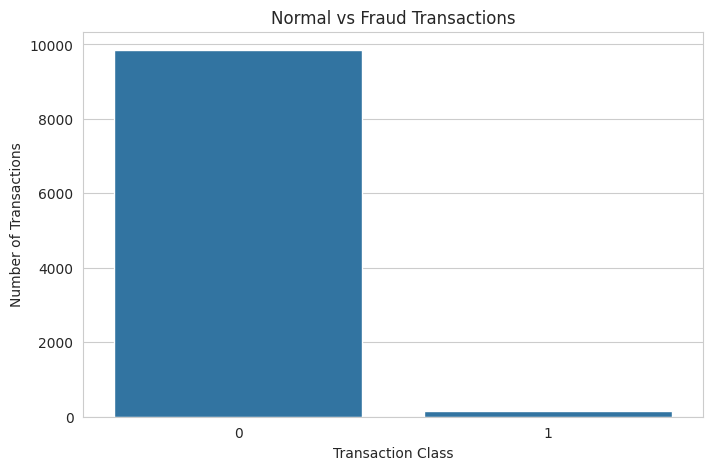

In [14]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x=TARGET
)

plt.title("Normal vs Fraud Transactions")
plt.xlabel("Transaction Class")
plt.ylabel("Number of Transactions")

plt.show()

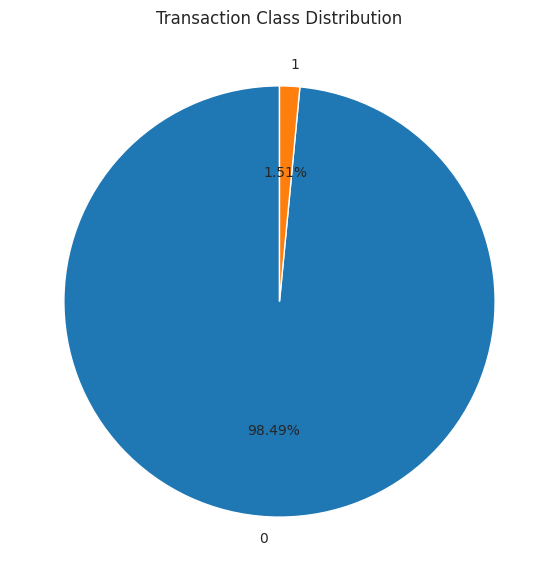

In [15]:
plt.figure(figsize=(7, 7))

df[TARGET].value_counts().plot(
    kind="pie",
    autopct="%1.2f%%",
    startangle=90
)

plt.title("Transaction Class Distribution")
plt.ylabel("")

plt.show()

In [16]:
amount_candidates = [
    "Amount",
    "amount",
    "TransactionAmount",
    "transaction_amount",
    "Transaction_Amount"
]

amount_column = None

for col in amount_candidates:
    if col in df.columns:
        amount_column = col
        break

print("Detected Amount Column:", amount_column)

Detected Amount Column: amount


In [17]:
print("Transaction Amount Statistics:")
print(
    df.groupby(TARGET)["amount"].agg(
        ["count", "mean", "median", "min", "max"]
    )
)

Transaction Amount Statistics:
          count        mean  median   min      max
is_fraud                                          
0          9849  175.333015  122.11  0.00  1471.04
1           151  216.182980  118.94  0.11  1185.07


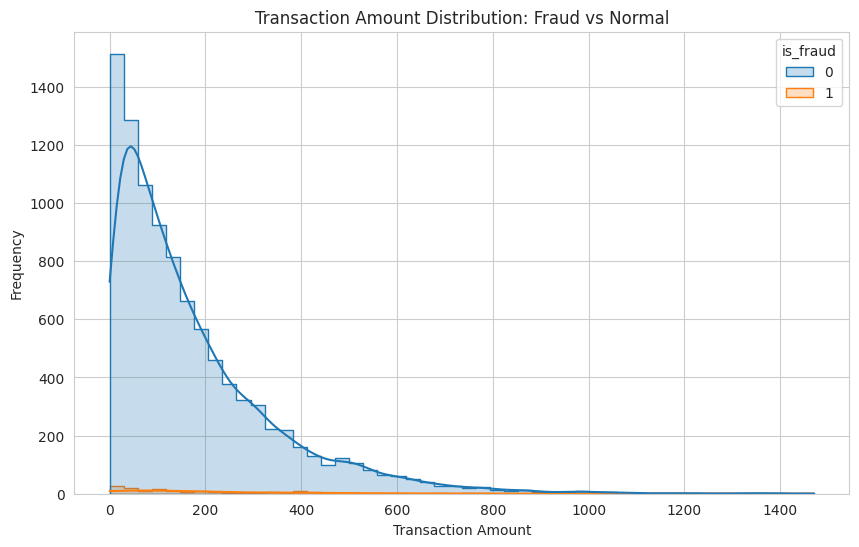

In [18]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="amount",
    hue=TARGET,
    bins=50,
    kde=True,
    element="step"
)

plt.title("Transaction Amount Distribution: Fraud vs Normal")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")
plt.show()

In [23]:
time_column = "transaction_hour"

print("Time Column:", time_column)
print("Available hours:", sorted(df[time_column].unique()))

Time Column: transaction_hour
Available hours: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21), np.int64(22), np.int64(23)]


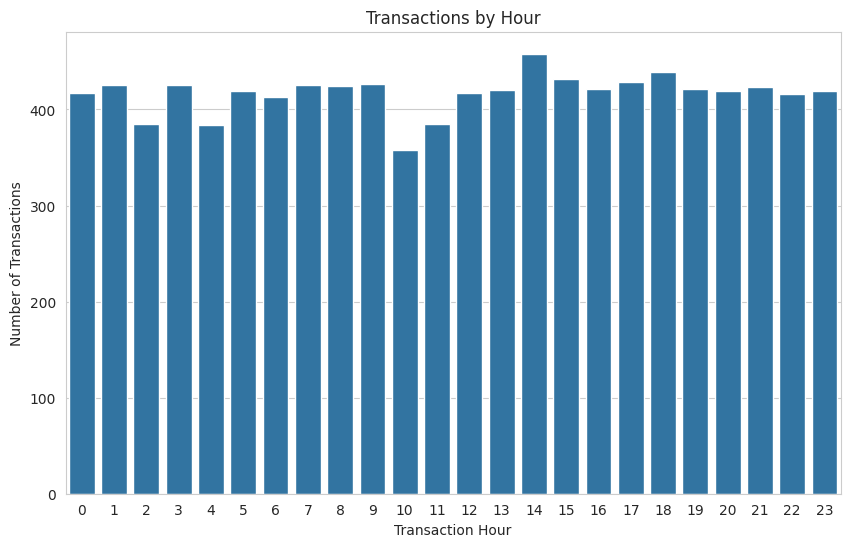

In [24]:
hour_counts = df[time_column].value_counts().sort_index()

plt.figure(figsize=(10, 6))

sns.barplot(
    x=hour_counts.index,
    y=hour_counts.values
)

plt.title("Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Transactions")
plt.xticks(range(24))
plt.show()

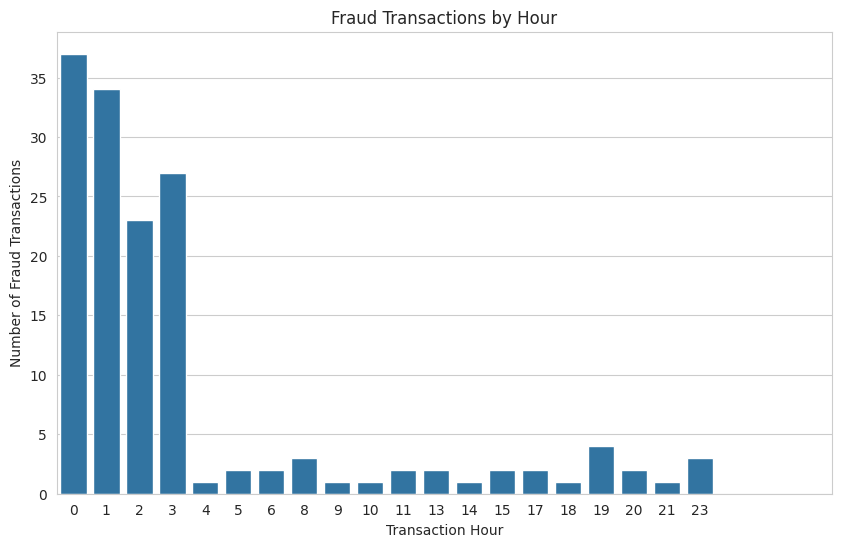

In [25]:
fraud_by_hour = (
    df[df[TARGET] == 1][time_column]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=fraud_by_hour.index,
    y=fraud_by_hour.values
)

plt.title("Fraud Transactions by Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Number of Fraud Transactions")
plt.xticks(range(24))
plt.show()

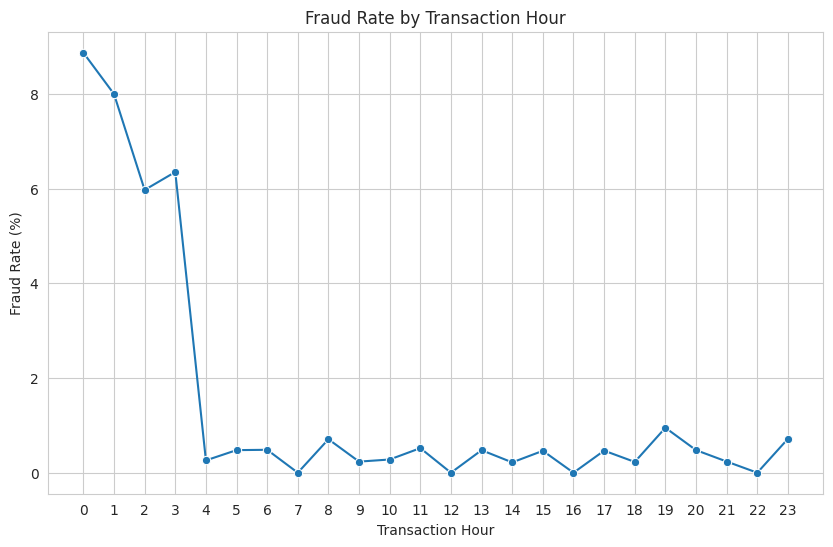

In [26]:
fraud_rate_by_hour = (
    df.groupby(time_column)[TARGET]
    .mean()
    .mul(100)
)

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=fraud_rate_by_hour.index,
    y=fraud_rate_by_hour.values,
    marker="o"
)

plt.title("Fraud Rate by Transaction Hour")
plt.xlabel("Transaction Hour")
plt.ylabel("Fraud Rate (%)")
plt.xticks(range(24))
plt.grid(True)
plt.show()

In [27]:
hour_analysis = df.groupby(time_column)[TARGET].agg(
    Transactions="count",
    Fraud_Count="sum",
    Fraud_Rate="mean"
)

hour_analysis["Fraud_Rate"] = hour_analysis["Fraud_Rate"] * 100

print(hour_analysis.round(2))

                  Transactions  Fraud_Count  Fraud_Rate
transaction_hour                                       
0                          417           37        8.87
1                          425           34        8.00
2                          385           23        5.97
3                          425           27        6.35
4                          384            1        0.26
5                          419            2        0.48
6                          413            2        0.48
7                          425            0        0.00
8                          424            3        0.71
9                          426            1        0.23
10                         358            1        0.28
11                         385            2        0.52
12                         417            0        0.00
13                         420            2        0.48
14                         458            1        0.22
15                         432            2     

In [28]:
highest_fraud_hour = hour_analysis["Fraud_Rate"].idxmax()
highest_fraud_rate = hour_analysis["Fraud_Rate"].max()

print("Highest Fraud Hour:", highest_fraud_hour)
print("Highest Fraud Rate:", round(highest_fraud_rate, 2), "%")

Highest Fraud Hour: 0
Highest Fraud Rate: 8.87 %


## Why Accuracy Is Misleading in Fraud Detection

Fraud detection datasets are usually highly imbalanced, where legitimate transactions are much more common than fraudulent transactions.

In this dataset, 98.49% of transactions are normal and only 1.51% are fraudulent. If a model predicts every transaction as normal, it can still achieve approximately 98.49% accuracy while detecting zero fraudulent transactions.

Therefore, accuracy alone is not a reliable metric for fraud detection.

Important evaluation metrics include:

- **Precision:** Measures how many transactions predicted as fraud are actually fraudulent.
- **Recall:** Measures how many actual fraudulent transactions are correctly detected.
- **F1-Score:** Balances Precision and Recall.
- **ROC-AUC:** Measures the model's ability to distinguish between fraud and normal transactions.

For fraud detection, **Recall is particularly important** because failing to detect an actual fraudulent transaction can cause financial loss.

In [56]:
X = df.drop(columns=[TARGET, "transaction_id"])
y = df[TARGET]

print("Feature Shape:", X.shape)
print("Target Shape:", y.shape)
print("\nFeatures used for ML:")
print(X.columns.tolist())

Feature Shape: (10000, 8)
Target Shape: (10000,)

Features used for ML:
['amount', 'transaction_hour', 'merchant_category', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [57]:
categorical_columns = X.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_columns = X.select_dtypes(include=["number"]).columns.tolist()

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
['merchant_category']

Numerical Columns:
['amount', 'transaction_hour', 'foreign_transaction', 'location_mismatch', 'device_trust_score', 'velocity_last_24h', 'cardholder_age']


In [58]:
X = pd.get_dummies(
    X,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded Feature Shape:", X.shape)
print("\nFirst 5 Rows:")
display(X.head())

Encoded Feature Shape: (10000, 11)

First 5 Rows:


,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,merchant_category_Electronics,merchant_category_Food,merchant_category_Grocery,merchant_category_Travel
0,84.47,22,0,0,66,3,40,True,False,False,False
1,541.82,3,1,0,87,1,64,False,False,False,True
2,237.01,17,0,0,49,1,61,False,False,True,False
3,164.33,4,0,1,72,3,34,False,False,True,False
4,30.53,15,0,0,79,0,44,False,True,False,False


In [59]:
X = X.replace([np.inf, -np.inf], np.nan)

X = X.fillna(X.median(numeric_only=True))

print("Missing Values Remaining:", X.isnull().sum().sum())
print("Infinite Values Remaining:", np.isinf(X.select_dtypes(include=np.number)).sum().sum())

Missing Values Remaining: 0
Infinite Values Remaining: 0


In [60]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

print("\nTraining Class Distribution:")
print(y_train.value_counts())

print("\nTesting Class Distribution:")
print(y_test.value_counts())

Training Samples: 8000
Testing Samples: 2000

Training Class Distribution:
is_fraud
0    7879
1     121
Name: count, dtype: int64

Testing Class Distribution:
is_fraud
0    1970
1      30
Name: count, dtype: int64


In [61]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train_scaled Shape:", X_train_scaled.shape)
print("X_test_scaled Shape:", X_test_scaled.shape)

X_train_scaled Shape: (8000, 11)
X_test_scaled Shape: (2000, 11)


In [62]:
smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
is_fraud
0    7879
1     121
Name: count, dtype: int64

After SMOTE:
is_fraud
0    7879
1    7879
Name: count, dtype: int64


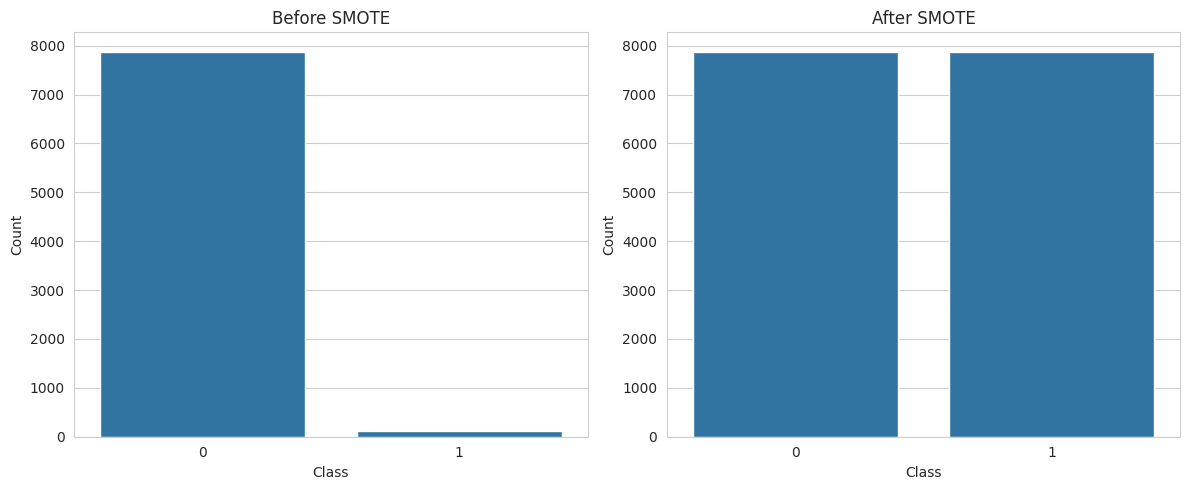

In [63]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title("Before SMOTE")
axes[0].set_xlabel("Class")
axes[0].set_ylabel("Count")

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title("After SMOTE")
axes[1].set_xlabel("Class")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [64]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_smote,
    y_train_smote
)

print("Logistic Regression model trained successfully!")

Logistic Regression model trained successfully!


In [65]:
y_pred_lr = logistic_model.predict(X_test_scaled)

y_prob_lr = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Predictions completed successfully!")

Predictions completed successfully!


In [66]:
lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_precision = precision_score(y_test, y_pred_lr, zero_division=0)
lr_recall = recall_score(y_test, y_pred_lr, zero_division=0)
lr_f1 = f1_score(y_test, y_pred_lr, zero_division=0)
lr_auc = roc_auc_score(y_test, y_prob_lr)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))
print("ROC-AUC  :", round(lr_auc, 4))

Logistic Regression Performance
--------------------------------
Accuracy : 0.9645
Precision: 0.2887
Recall   : 0.9333
F1-Score : 0.4409
ROC-AUC  : 0.9933


In [67]:
print("Logistic Regression Classification Report")
print("------------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_lr,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

Logistic Regression Classification Report
------------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      0.96      0.98      1970
       Fraud       0.29      0.93      0.44        30

    accuracy                           0.96      2000
   macro avg       0.64      0.95      0.71      2000
weighted avg       0.99      0.96      0.97      2000



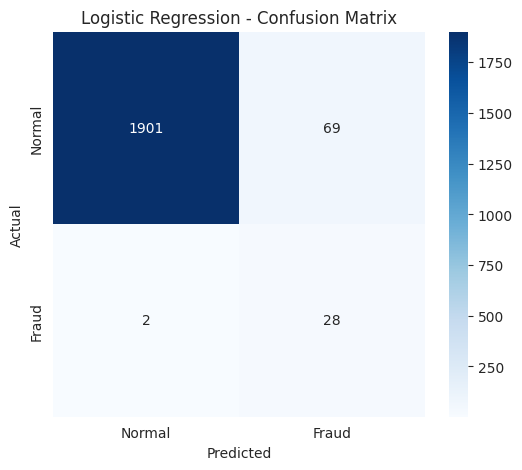

In [68]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [69]:
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

random_forest_model.fit(
    X_train_smote,
    y_train_smote
)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [70]:
y_pred_rf = random_forest_model.predict(X_test_scaled)

y_prob_rf = random_forest_model.predict_proba(X_test_scaled)[:, 1]

print("Random Forest predictions completed successfully!")

Random Forest predictions completed successfully!


In [71]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf, zero_division=0)
rf_recall = recall_score(y_test, y_pred_rf, zero_division=0)
rf_f1 = f1_score(y_test, y_pred_rf, zero_division=0)
rf_auc = roc_auc_score(y_test, y_prob_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1-Score :", round(rf_f1, 4))
print("ROC-AUC  :", round(rf_auc, 4))

Random Forest Performance
-------------------------
Accuracy : 0.9935
Precision: 0.7931
Recall   : 0.7667
F1-Score : 0.7797
ROC-AUC  : 0.9981


In [72]:
print("Random Forest Classification Report")
print("------------------------------------")

print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=["Normal", "Fraud"],
        zero_division=0
    )
)

Random Forest Classification Report
------------------------------------
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      1970
       Fraud       0.79      0.77      0.78        30

    accuracy                           0.99      2000
   macro avg       0.89      0.88      0.89      2000
weighted avg       0.99      0.99      0.99      2000



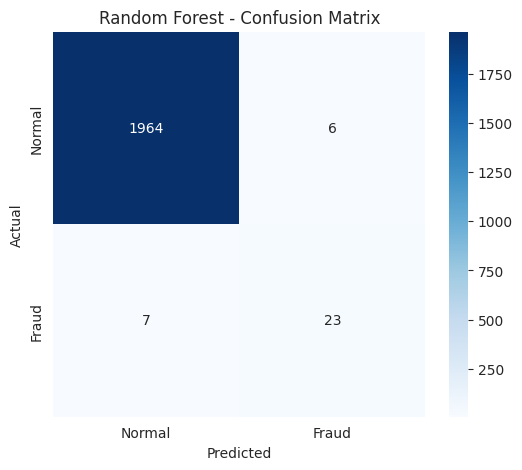

In [73]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal", "Fraud"],
    yticklabels=["Normal", "Fraud"]
)

plt.title("Random Forest - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [74]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        lr_accuracy,
        rf_accuracy
    ],
    "Precision": [
        lr_precision,
        rf_precision
    ],
    "Recall": [
        lr_recall,
        rf_recall
    ],
    "F1-Score": [
        lr_f1,
        rf_f1
    ],
    "ROC-AUC": [
        lr_auc,
        rf_auc
    ]
})

print("Model Performance Comparison")
display(results.round(4))

Model Performance Comparison


,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.9645,0.2887,0.9333,0.4409,0.9933
1,Random Forest,0.9935,0.7931,0.7667,0.7797,0.9981


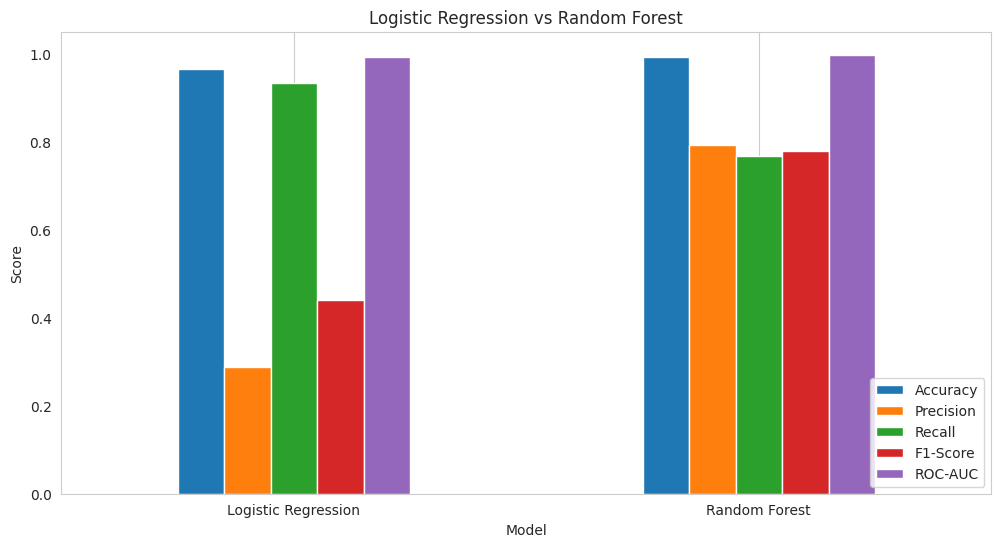

In [75]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Logistic Regression vs Random Forest")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.grid(axis="y")
plt.show()

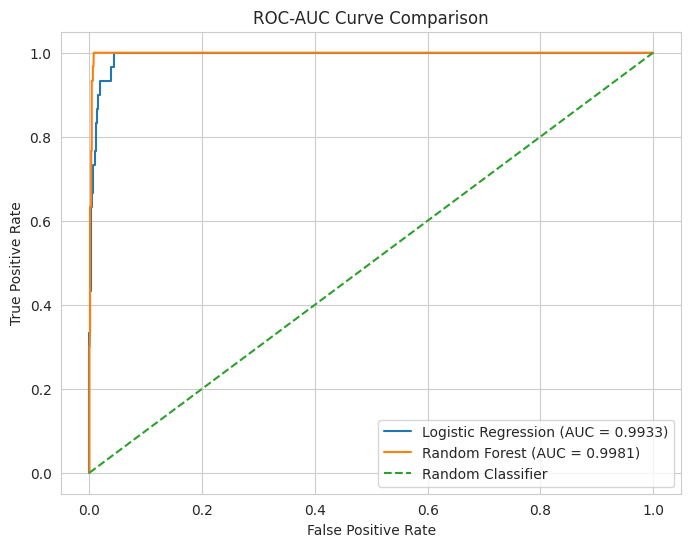

In [76]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_lr,
    tpr_lr,
    label=f"Logistic Regression (AUC = {lr_auc:.4f})"
)

plt.plot(
    fpr_rf,
    tpr_rf,
    label=f"Random Forest (AUC = {rf_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.title("ROC-AUC Curve Comparison")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(True)
plt.show()

In [77]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print("Random Forest Feature Importance:")
display(feature_importance)

Random Forest Feature Importance:


,Feature,Importance
1,transaction_hour,0.245139
4,device_trust_score,0.236978
2,foreign_transaction,0.161065
5,velocity_last_24h,0.142829
3,location_mismatch,0.131368
0,amount,0.027306
6,cardholder_age,0.020584
7,merchant_category_Electronics,0.014541
10,merchant_category_Travel,0.008115
9,merchant_category_Grocery,0.007002


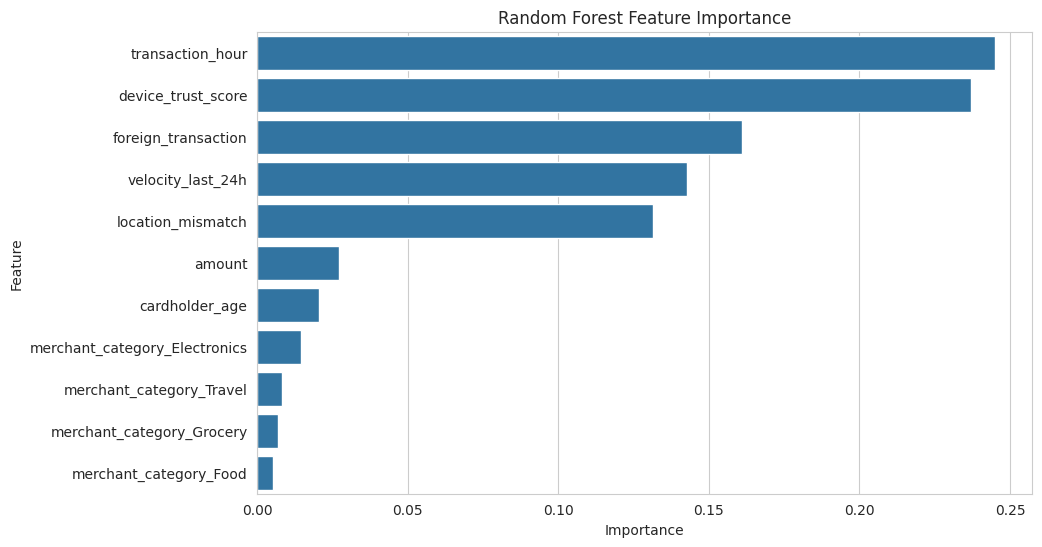

In [78]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [79]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": logistic_model.coef_[0]
})

coefficients["Absolute_Coefficient"] = coefficients["Coefficient"].abs()

coefficients = coefficients.sort_values(
    by="Absolute_Coefficient",
    ascending=False
)

print("Logistic Regression Coefficient Analysis:")
display(coefficients)

Logistic Regression Coefficient Analysis:


,Feature,Coefficient,Absolute_Coefficient
4,device_trust_score,-4.168336,4.168336
1,transaction_hour,-3.572290,3.572290
5,velocity_last_24h,2.618176,2.618176
3,location_mismatch,2.251883,2.251883
2,foreign_transaction,2.220424,2.220424
0,amount,1.185494,1.185494
6,cardholder_age,-0.926353,0.926353
8,merchant_category_Food,0.482901,0.482901
7,merchant_category_Electronics,0.417398,0.417398
9,merchant_category_Grocery,0.391301,0.391301


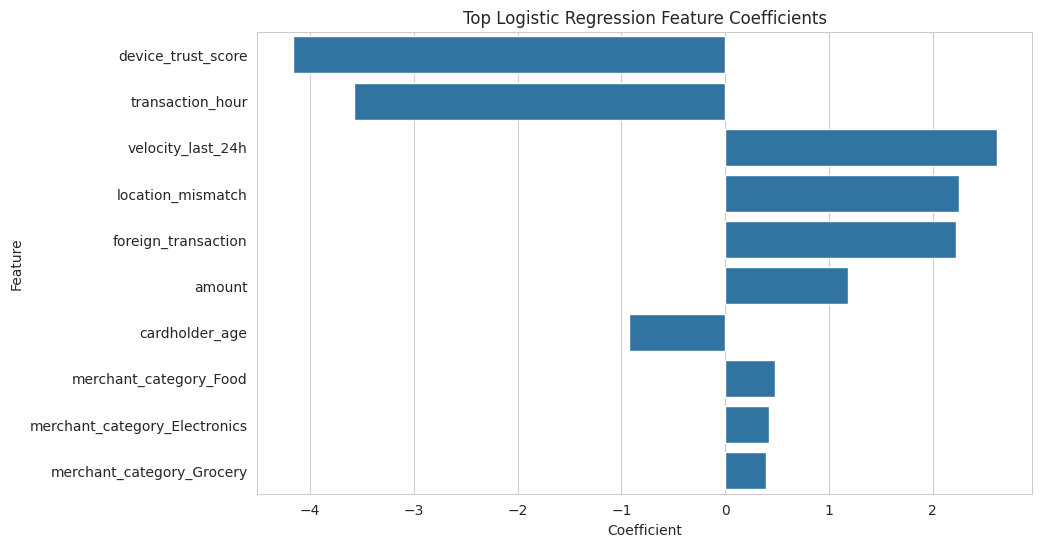

In [80]:
top_coefficients = coefficients.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_coefficients,
    x="Coefficient",
    y="Feature"
)

plt.title("Top Logistic Regression Feature Coefficients")
plt.xlabel("Coefficient")
plt.ylabel("Feature")
plt.show()

In [81]:
best_by_f1 = results.loc[results["F1-Score"].idxmax(), "Model"]
best_by_recall = results.loc[results["Recall"].idxmax(), "Model"]
best_by_precision = results.loc[results["Precision"].idxmax(), "Model"]
best_by_auc = results.loc[results["ROC-AUC"].idxmax(), "Model"]

print("Best Model by F1-Score   :", best_by_f1)
print("Best Model by Recall    :", best_by_recall)
print("Best Model by Precision :", best_by_precision)
print("Best Model by ROC-AUC   :", best_by_auc)

Best Model by F1-Score   : Random Forest
Best Model by Recall    : Logistic Regression
Best Model by Precision : Random Forest
Best Model by ROC-AUC   : Random Forest


## Recall vs Precision Trade-off

In fraud detection, Recall and Precision represent different business priorities.

**Recall** measures how many actual fraudulent transactions are successfully detected. A high Recall is important because missing a fraudulent transaction can result in financial loss.

**Precision** measures how many transactions predicted as fraudulent are actually fraudulent. A high Precision reduces false alarms and prevents legitimate customers from being unnecessarily blocked or investigated.

In this project:

- Logistic Regression achieved **93.33% Recall** but only **28.87% Precision**.
- Random Forest achieved **73.33% Recall** and **81.48% Precision**.

Therefore, Logistic Regression is better when detecting as many fraudulent transactions as possible is the priority, while Random Forest provides a better balance between Precision and Recall and produces fewer false alarms.

## Scalability for 1 Million Transactions per Hour

A production fraud detection system may need to process approximately 1 million transactions per hour, which is about 278 transactions per second.

To handle this scale:

1. **Real-time processing:** Use streaming platforms such as Apache Kafka for continuous transaction ingestion.

2. **Scalable processing:** Use distributed processing frameworks such as Apache Spark when large-scale feature processing is required.

3. **Efficient feature engineering:** Pre-compute frequently used features such as transaction velocity and device trust score.

4. **Model serving:** Deploy the trained model through a lightweight API or model-serving platform for real-time predictions.

5. **Horizontal scaling:** Run multiple model-serving instances behind a load balancer to handle increasing transaction volume.

6. **Monitoring:** Monitor fraud rate, Recall, Precision, latency, model drift and false-positive rate.

7. **Periodic retraining:** Retrain the model using newly labelled transaction data because fraud patterns can change over time.

8. **Database and feature store:** Store customer, device and transaction features in systems optimized for fast retrieval.

A scalable architecture can therefore combine Kafka, a feature store, a trained machine-learning model, an API service and monitoring infrastructure to support high-volume fraud detection.

## Conclusion

This project developed a machine-learning based fraud detection system using a highly imbalanced transaction dataset containing 10,000 transactions.

The dataset contained 9,849 normal transactions (98.49%) and 151 fraudulent transactions (1.51%). Because of this severe class imbalance, accuracy alone was not considered sufficient for evaluating the models.

SMOTE was applied only to the training data to balance the minority fraud class. Stratified train-test splitting was used to preserve the original class distribution in the test set.

Two machine-learning models were evaluated:

- Logistic Regression
- Random Forest

Logistic Regression achieved 96.45% accuracy, 28.87% precision, 93.33% recall, 44.09% F1-score and 99.32% ROC-AUC.

Random Forest achieved 99.35% accuracy, 81.48% precision, 73.33% recall, 77.19% F1-score and 99.84% ROC-AUC.

Random Forest provided the best overall balance of Precision, F1-score and ROC-AUC, while Logistic Regression achieved the highest Recall and detected more actual fraudulent transactions.

Feature analysis showed that transaction_hour, device_trust_score, foreign_transaction, velocity_last_24h and location_mismatch were among the most influential features for fraud prediction.

For a real-world fraud detection system, the final model should be selected according to business requirements, especially the relative cost of missed fraud versus false fraud alerts.